In [110]:
import pandas as pd 
import seaborn as sns 
import numpy as np 
import matplotlib.pyplot as plt 
import scipy.stats as stats 
from pandas.plotting import parallel_coordinates 
from statsmodels.graphics.mosaicplot import mosaic 
import math 
from datetime import datetime

In [34]:
teste1 = pd.read_excel('corr_teste1.xlsx', decimal = ',')
teste1.columns = teste1.iloc[0]
teste1.drop(teste1.index[0], axis = 0, inplace = True )
teste1.reset_index(drop = True, inplace = True)
variaveis = ['vacuo ','temp ','vel ','umidade','acidez ','AR']
for i in variaveis:
    teste1[i] = teste1[i].astype('float')
teste1
analise1 = teste1[variaveis]
analise1

,vacuo,temp,vel,umidade,acidez,AR
0,300.0,132.0,691.0,3.14,0.02,17.67
1,295.0,132.0,650.0,3.08,0.03,17.96
2,290.0,132.0,700.0,3.06,0.02,15.12
3,297.0,131.0,698.0,3.04,0.02,15.42
4,295.0,131.0,746.0,3.16,0.02,15.61
...,...,...,...,...,...,...
140,299.0,137.0,722.0,2.87,1.73,18.81
141,292.0,131.0,698.0,3.28,0.02,18.37
142,296.0,131.0,686.0,3.00,0.02,19.02
143,294.0,132.0,712.0,3.09,0.02,18.07


In [35]:
analise1.describe()

,vacuo,temp,vel,umidade,acidez,AR
count,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000
mean,296.800000,132.510345,698.565517,5.297793,0.299586,17.649517
std,3.402613,1.867549,13.625351,26.065805,0.665572,1.693565
min,290.000000,130.000000,638.000000,2.790000,0.020000,14.380000
25%,295.000000,131.000000,691.000000,3.030000,0.020000,16.070000
50%,296.000000,132.000000,700.000000,3.090000,0.020000,17.960000
75%,299.000000,133.000000,708.000000,3.200000,0.030000,18.960000
max,307.000000,139.000000,746.000000,317.000000,4.160000,23.260000


In [36]:
#index = analise1[analise1['umidade'] == analise1['umidade'].max() ].index
analise1 = analise1.drop(analise1.index[136])
analise1.reset_index(drop  = True, inplace = True )
analise1.describe()


,vacuo,temp,vel,umidade,acidez,AR
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000
mean,296.826389,132.513889,698.555556,3.133194,0.301528,17.640694
std,3.399568,1.873578,13.672379,0.175303,0.667483,1.696129
min,290.000000,130.000000,638.000000,2.790000,0.020000,14.380000
25%,295.000000,131.000000,691.000000,3.030000,0.020000,16.060000
50%,296.500000,132.000000,700.000000,3.090000,0.020000,17.945000
75%,299.000000,133.000000,708.000000,3.200000,0.030000,18.962500
max,307.000000,139.000000,746.000000,3.830000,4.160000,23.260000


<Axes: xlabel='produto ', ylabel='umidade'>

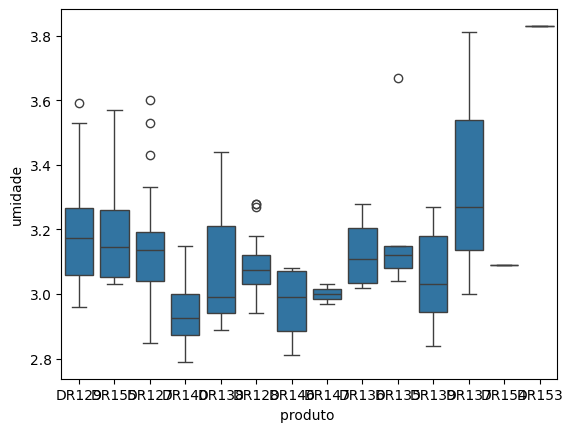

In [37]:
teste1 = teste1.drop(teste1.index[136])
sns.boxplot(data = teste1, x = 'produto ', y = 'umidade')


In [33]:
class_produtos = teste1.groupby('produto ')['umidade'].describe()
class_produtos


,count,mean,std,min,25%,50%,75%,max
produto,,,,,,,,
DR127,32.0,3.150625,0.158500,2.85,3.0400,3.135,3.1925,3.60
DR128,28.0,3.083929,0.088122,2.94,3.0300,3.075,3.1200,3.28
DR129,38.0,3.173947,0.145334,2.96,3.0600,3.175,3.2650,3.59
DR135,5.0,3.212000,0.259365,3.04,3.0800,3.120,3.1500,3.67
DR136,4.0,3.130000,0.122746,3.02,3.0350,3.110,3.2050,3.28
DR137,3.0,3.360000,0.412432,3.00,3.1350,3.270,3.5400,3.81
DR138,5.0,3.094000,0.228758,2.89,2.9400,2.990,3.2100,3.44
DR139,10.0,3.048000,0.150170,2.84,2.9450,3.030,3.1800,3.27
DR140,4.0,2.947500,0.150638,2.79,2.8725,2.925,3.0000,3.15


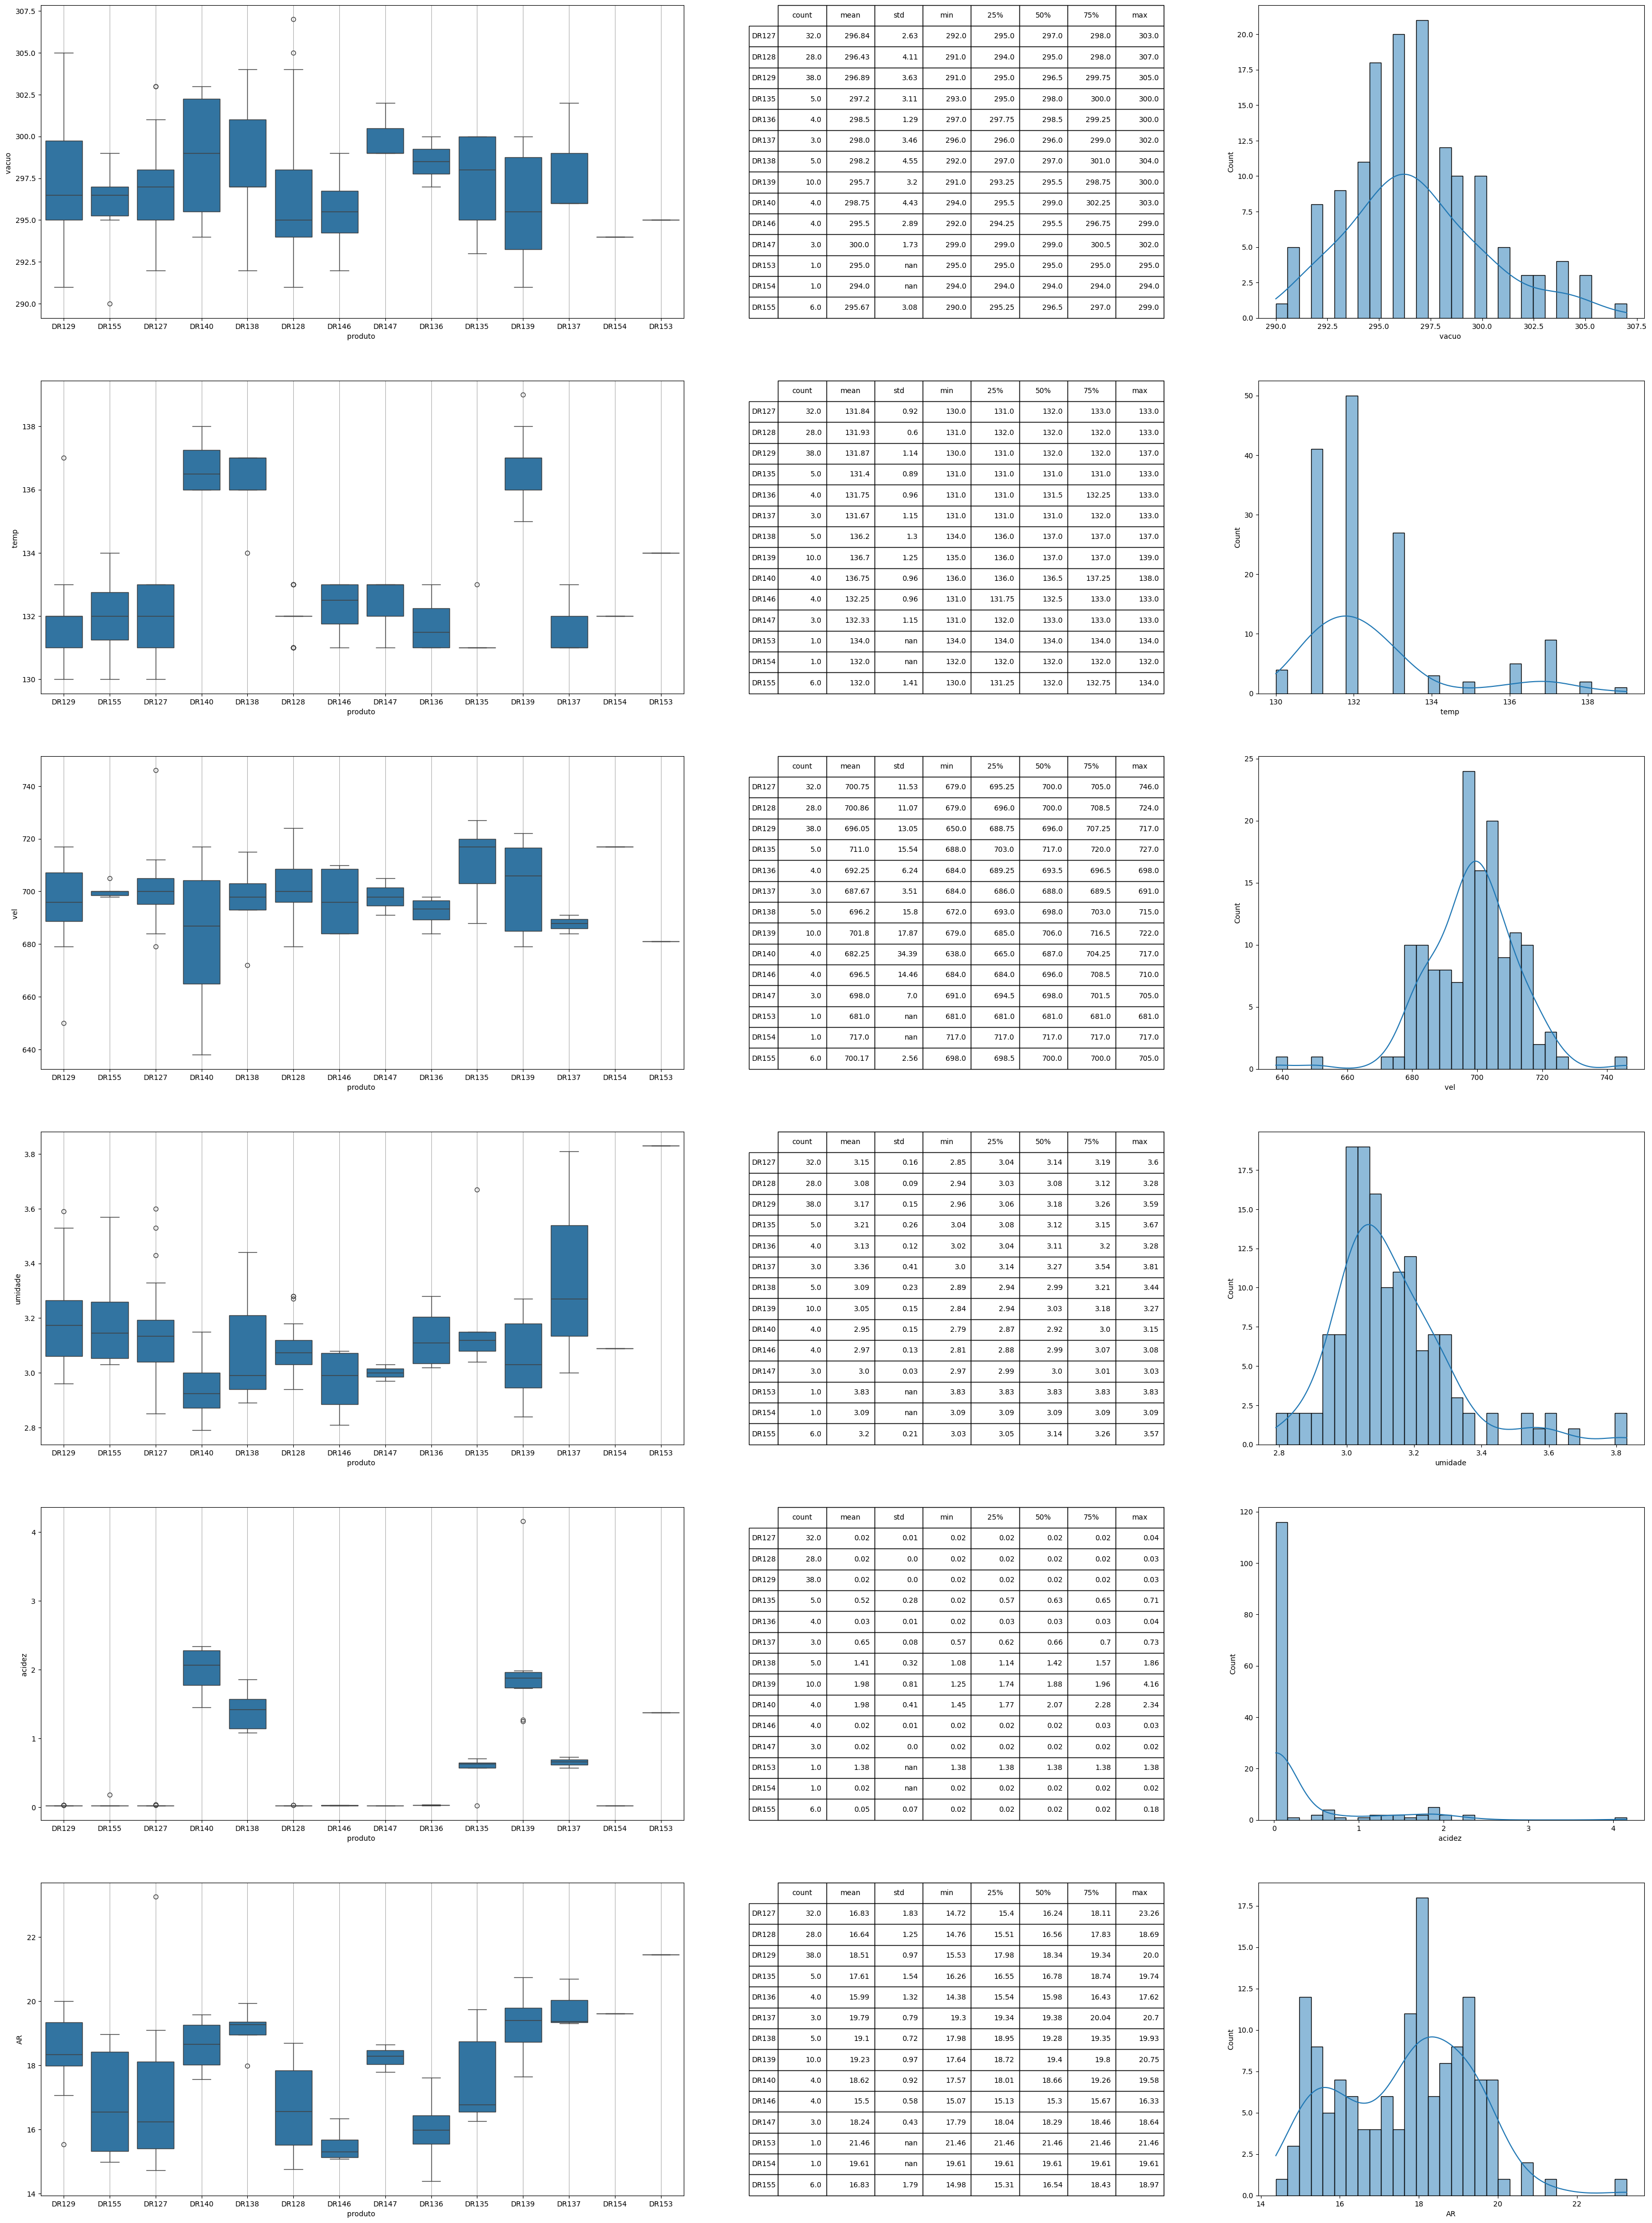

In [84]:

analise1 = teste1[variaveis]
descritivo = analise1.describe()
fig, axes = plt.subplots(len(variaveis),3, figsize = (40,55), width_ratios=[1,0.6,0.6])
for i in range(0,len(variaveis)):
    sns.boxplot(ax = axes[i,0], data = teste1, x = 'produto ', y = variaveis[i])
    axes[i,0].grid(axis = 'x')
    
    dados = teste1.groupby('produto ')[variaveis[i]].describe()
    descr = axes[i,1].table(cellText = dados.values.round(2),rowLabels=dados.index,colLabels= dados.columns , bbox = [0,0,1,1])
    descr.auto_set_font_size(False)
    descr.set_fontsize(10)
    axes[i,1].set(xticks = ([]), yticks = ([]))

    sns.histplot(ax = axes[i,2], data = teste1, x = variaveis[i], bins = 30, alpha = 0.5, kde = True )
    


In [148]:
variaveis

['vacuo ', 'temp ', 'vel ', 'umidade', 'acidez ', 'AR']

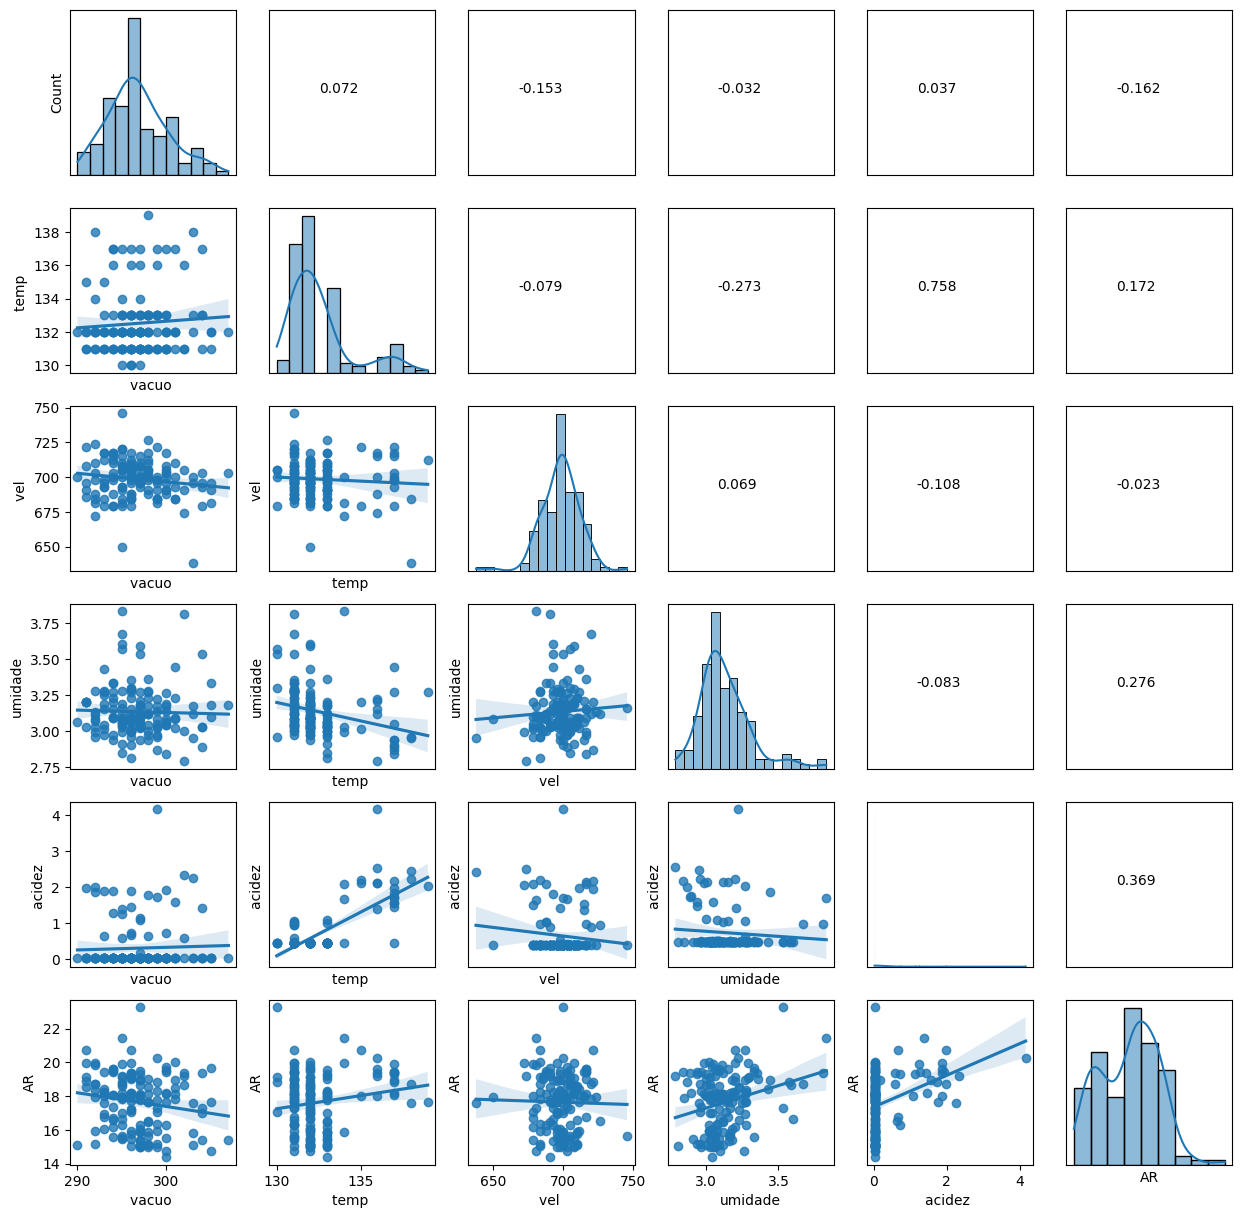

In [178]:
def matriz_corr(data, vars)
figura, axes = plt.subplots(len(variaveis),len(variaveis), figsize = (15,15))
correlacao = analise1.corr()
for i in range(0,len(variaveis)):
    for j in range(0,len(variaveis)):
        
        if i < len(variaveis)-1:
            axes[i,j].set(xticks = ([]))
        if j > 0 :
            axes[i,j].set(yticks = ([]))

        
        if i>j:
            sns.regplot(ax = axes[i,j], data = teste1, x = teste1[variaveis[j]], y = teste1[variaveis[i]])

            
        elif i<j:
            axes[i,j].text(0.3,0.5,correlacao.iloc[j,i].round(3))
            
        else:
            sns.histplot(ax = axes[i,j], data = teste1, x = variaveis[i], kde = True)
            axes[i,j].set(xticks = ([]), yticks = ([]))
        
            
        

    

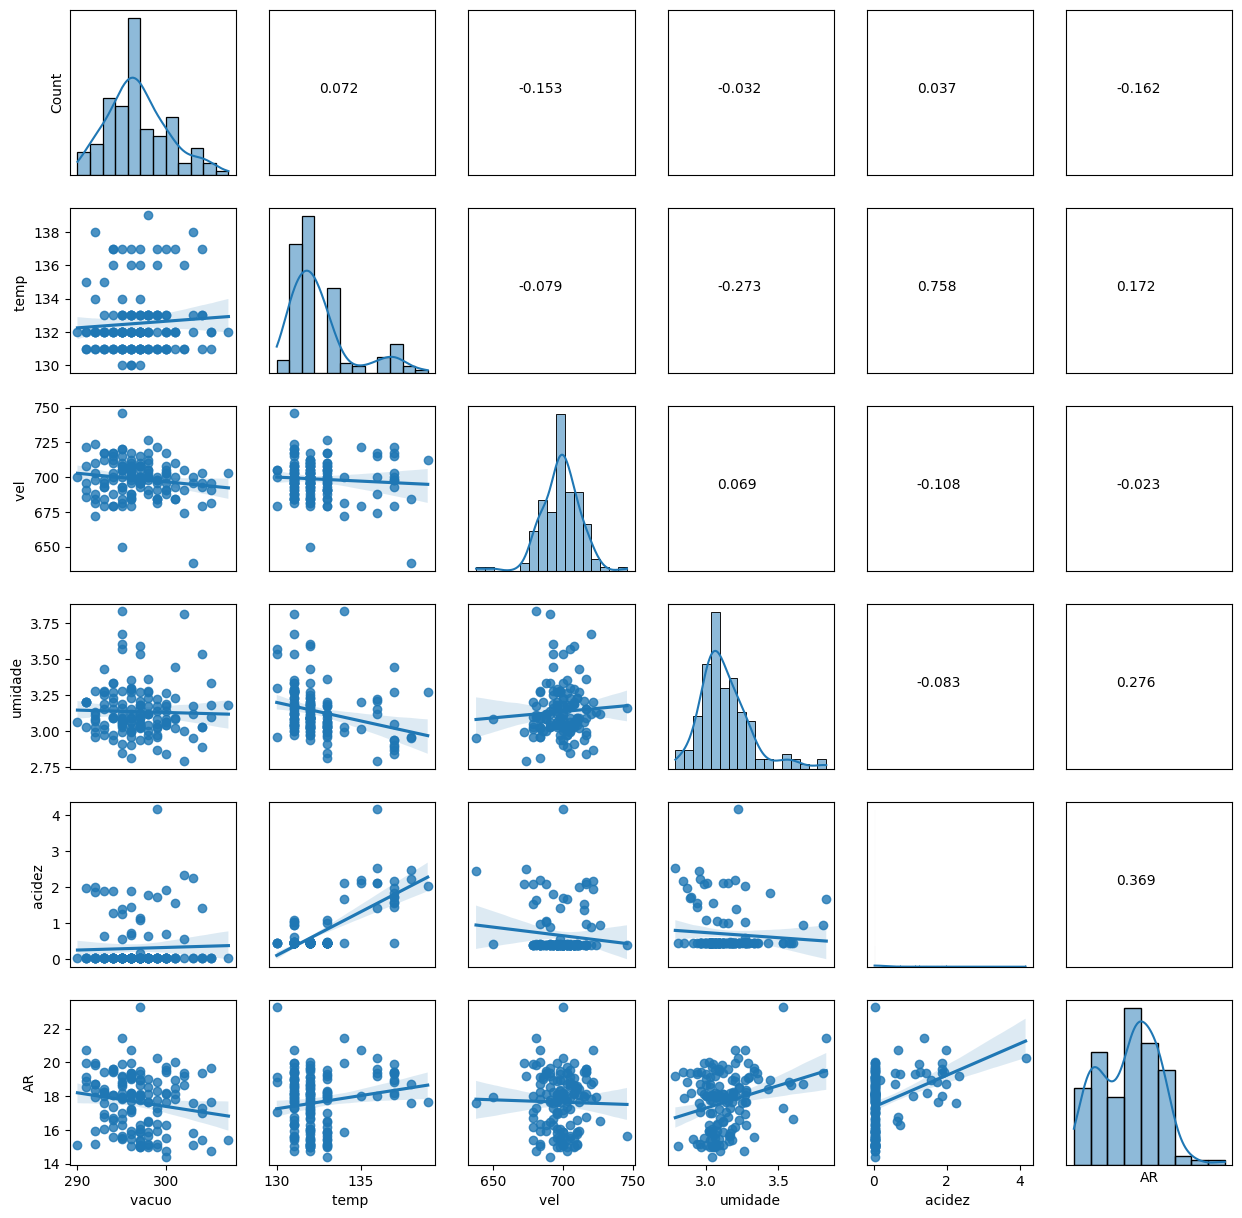

In [180]:
figura, axes = plt.subplots(len(variaveis),len(variaveis), figsize = (15,15))
correlacao = analise1.corr()
for i in range(0,len(variaveis)):
    for j in range(0,len(variaveis)):
        
        if i>j:
            sns.regplot(ax = axes[i,j], data = teste1, x = teste1[variaveis[j]], y = teste1[variaveis[i]])
            
        elif i<j:
            axes[i,j].text(0.3,0.5,correlacao.iloc[j,i].round(3))
            
        else:
            sns.histplot(ax = axes[i,j], data = teste1, x = variaveis[i], kde = True)
            axes[i,j].set(xticks = ([]), yticks = ([]))

        if i < len(variaveis)-1:
            axes[i,j].set(xticks = ([]), xlabel = '')
        if j > 0 :
            axes[i,j].set(yticks = ([]), ylabel = '')
        
            